# 01 · Exploratory Data Analysis
Olist marketplace — revenue, categories, geography, customer retention, delivery. Run top-to-bottom after `python src/build_db.py`.

Each aggregate is also written to `data/processed/` as a clean CSV — those are the extracts the Tableau dashboard connects to.

In [11]:
# Anchor to the repo root so relative paths work whether this notebook is
# launched from the project folder or from notebooks/.
import os
from pathlib import Path
root = Path.cwd()
for _ in range(4):
    if (root / 'sql').exists():
        break
    root = root.parent
os.chdir(root)
print('Working directory:', Path.cwd())

Working directory: C:\Users\wassi\Desktop\retail-analytics


In [12]:
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style='whitegrid')
Path('data/processed').mkdir(parents=True, exist_ok=True)
Path('dashboard/screenshots').mkdir(parents=True, exist_ok=True)
con = duckdb.connect('data/olist.duckdb')

In [13]:
df = con.execute('SELECT * FROM fct_order_items').df()
print(f'{len(df):,} order-item rows | '
      f"{df['order_id'].nunique():,} orders | "
      f"{df['customer_unique_id'].nunique():,} customers")
df.head()

110,197 order-item rows | 96,478 orders | 93,358 customers


,order_id,order_item_id,customer_id,customer_unique_id,customer_state,product_id,category,order_status,purchase_ts,purchase_month,delivery_days,price,freight_value,gross_revenue
0,e17e4f88e31525f7deef66779844ddce,1,f8a3e963a310aa58b60a5b1fed5bceb5,b1a1199364a4a7fe27c4486ab63f550d,SP,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,delivered,2018-04-24 16:16:53,2018-04-01,3,10.91,7.39,18.30
1,5236307716393b7114b53ee991f36956,1,03fc97548af8f58fefc768d12b546c9c,4b86049cb99e4aa774031daa9cd18f18,RJ,3aa071139cb16b67ca9e5dea641aaa2f,art,delivered,2018-01-31 18:55:36,2018-01-01,16,248.00,17.99,265.99
2,01f66e58769f84129811d43eefd187fb,1,e41819d1c95c12c9ce495b630eab8aee,f63805d9c7edb84d92413af34b86a39c,SP,96bd76ec8810374ed1b65e291975717f,sports_leisure,delivered,2018-07-09 21:18:01,2018-07-01,2,79.80,7.82,87.62
3,143d00a4f2dde4e0364ee1821577adb3,1,322162b5ca010c2b059cb5224dd818b1,619e926d09b26efbd5180368b1ddc874,SP,cef67bcfe19066a932b7673e239eb23d,baby,delivered,2018-08-03 08:55:50,2018-08-01,3,112.30,9.54,121.84
4,86cafb8794cb99a9b1b77fc8e48fbbbb,1,c11c31965ff02cc1d7132df8edfcbc22,ad353b4fb0e294adc4eda48af73e68a6,SP,9dc1a7de274444849c219cff195d0b71,housewares,delivered,2018-04-11 01:06:37,2018-04-01,2,37.90,8.29,46.19


## Revenue over time

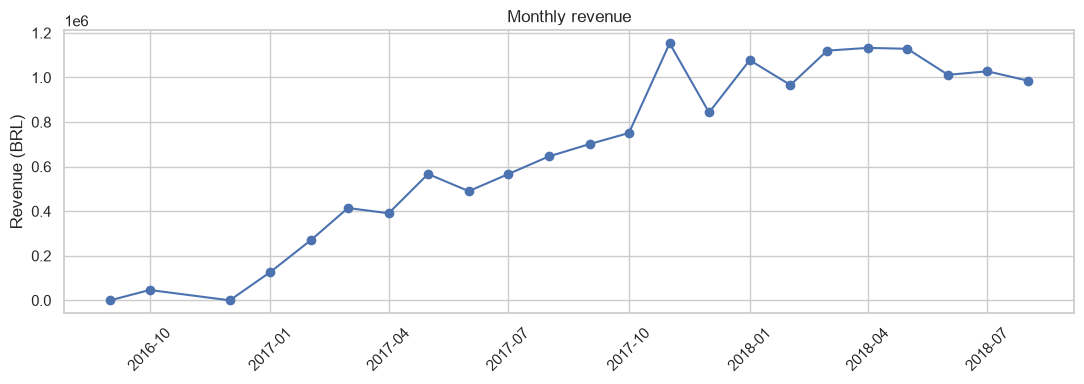

In [14]:
monthly = con.execute('''
  SELECT purchase_month,
         COUNT(DISTINCT order_id)                                AS orders,
         ROUND(SUM(gross_revenue), 2)                            AS revenue,
         ROUND(SUM(gross_revenue)/COUNT(DISTINCT order_id), 2)   AS aov
  FROM fct_order_items GROUP BY purchase_month ORDER BY purchase_month
''').df()
monthly.to_csv('data/processed/monthly_revenue.csv', index=False)

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(monthly['purchase_month'], monthly['revenue'], marker='o')
ax.set_title('Monthly revenue'); ax.set_ylabel('Revenue (BRL)')
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig('dashboard/screenshots/monthly_revenue.png', dpi=120)
plt.show()
# Note: the first/last month can be partial in Olist — read the trend, not the endpoints.

## Top product categories

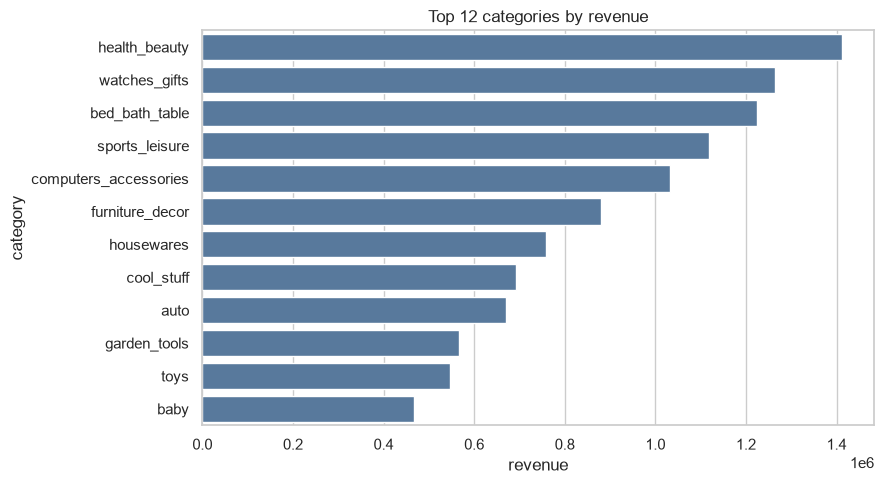

In [15]:
cat = con.execute('''
  SELECT category, ROUND(SUM(gross_revenue),2) AS revenue,
         COUNT(DISTINCT order_id) AS orders
  FROM fct_order_items GROUP BY category ORDER BY revenue DESC LIMIT 12
''').df()
cat.to_csv('data/processed/category_revenue.csv', index=False)

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(cat, y='category', x='revenue', ax=ax, color='#4C78A8')
ax.set_title('Top 12 categories by revenue'); plt.tight_layout()
plt.savefig('dashboard/screenshots/top_categories.png', dpi=120); plt.show()

## Revenue by state

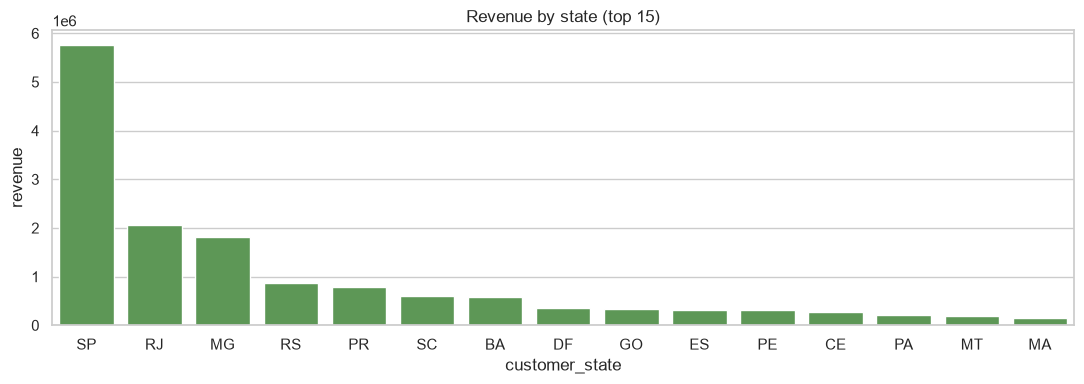

In [16]:
state = con.execute('''
  SELECT customer_state, ROUND(SUM(gross_revenue),2) AS revenue,
         COUNT(DISTINCT customer_unique_id) AS customers
  FROM fct_order_items GROUP BY customer_state ORDER BY revenue DESC
''').df()
state.to_csv('data/processed/state_revenue.csv', index=False)

fig, ax = plt.subplots(figsize=(11,4))
sns.barplot(state.head(15), x='customer_state', y='revenue', ax=ax, color='#54A24B')
ax.set_title('Revenue by state (top 15)'); plt.tight_layout()
plt.savefig('dashboard/screenshots/state_revenue.png', dpi=120); plt.show()

## The retention headline: one-time vs repeat customers

customer_type  customers  pct
       repeat       2801  3.0
     one-time      90557 97.0


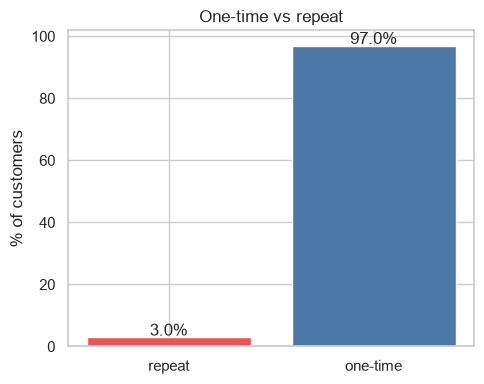

In [17]:
rep = con.execute('''
  WITH pc AS (SELECT customer_unique_id, COUNT(DISTINCT order_id) AS orders
              FROM fct_order_items GROUP BY 1)
  SELECT CASE WHEN orders=1 THEN 'one-time' ELSE 'repeat' END AS customer_type,
         COUNT(*) AS customers
  FROM pc GROUP BY 1
''').df()
rep['pct'] = (100*rep['customers']/rep['customers'].sum()).round(1)
print(rep.to_string(index=False))

fig, ax = plt.subplots(figsize=(5,4))
ax.bar(rep['customer_type'], rep['pct'], color=['#E45756','#4C78A8'])
ax.set_ylabel('% of customers'); ax.set_title('One-time vs repeat')
for i,v in enumerate(rep['pct']): ax.text(i, v+0.5, f'{v}%', ha='center')
plt.tight_layout(); plt.savefig('dashboard/screenshots/repeat_rate.png', dpi=120); plt.show()

## RFM customer segmentation
Runs `sql/03_rfm.sql` (Recency / Frequency / Monetary, scored 1–5 per customer).

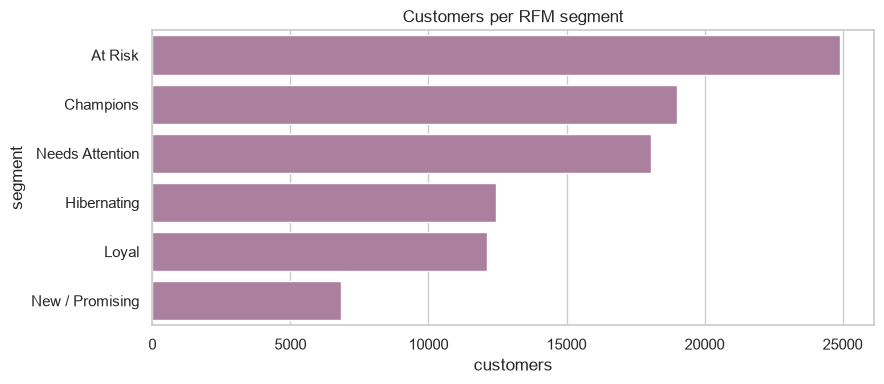

segment
At Risk            24893
Champions          19011
Needs Attention    18065
Hibernating        12451
Loyal              12110
New / Promising     6828
Name: count, dtype: int64

In [18]:
rfm = con.execute(open('sql/03_rfm.sql').read()).df()
rfm.to_csv('data/processed/rfm_segments.csv', index=False)
seg = rfm['segment'].value_counts()

fig, ax = plt.subplots(figsize=(9,4))
sns.barplot(x=seg.values, y=seg.index, ax=ax, color='#B279A2')
ax.set_title('Customers per RFM segment'); ax.set_xlabel('customers')
plt.tight_layout(); plt.savefig('dashboard/screenshots/rfm_segments.png', dpi=120); plt.show()
seg

## Cohort retention
Runs `sql/04_cohort_retention.sql`, pivots to a cohort × months-since-first matrix, and shows retention as a % of each cohort.

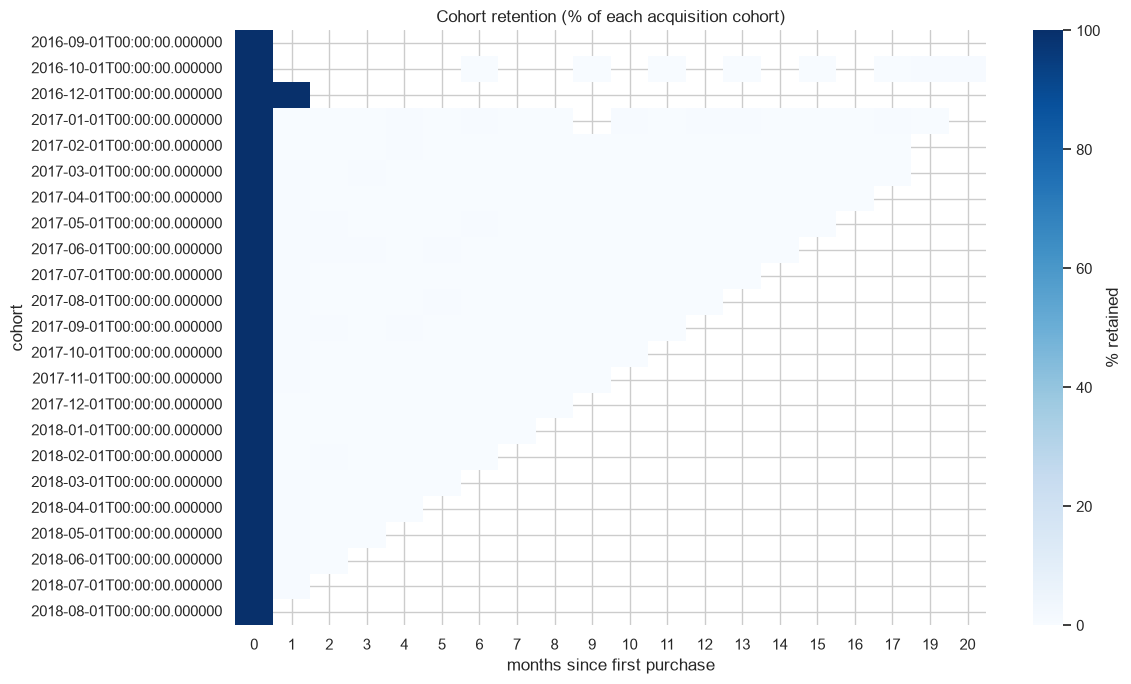

In [19]:
cohort = con.execute(open('sql/04_cohort_retention.sql').read()).df()
pivot = cohort.pivot(index='cohort_month', columns='month_offset', values='customers')
retention = pivot.divide(pivot[0], axis=0) * 100
retention.to_csv('data/processed/cohort_retention.csv')

plt.figure(figsize=(12,7))
sns.heatmap(retention, cmap='Blues', vmin=0, vmax=100,
            cbar_kws={'label':'% retained'})
plt.title('Cohort retention (% of each acquisition cohort)')
plt.xlabel('months since first purchase'); plt.ylabel('cohort')
plt.tight_layout(); plt.savefig('dashboard/screenshots/cohort_retention.png', dpi=120); plt.show()
# On Olist, columns past 0 are near-empty -> the marketplace barely retains. That IS the finding.

## Delivery time

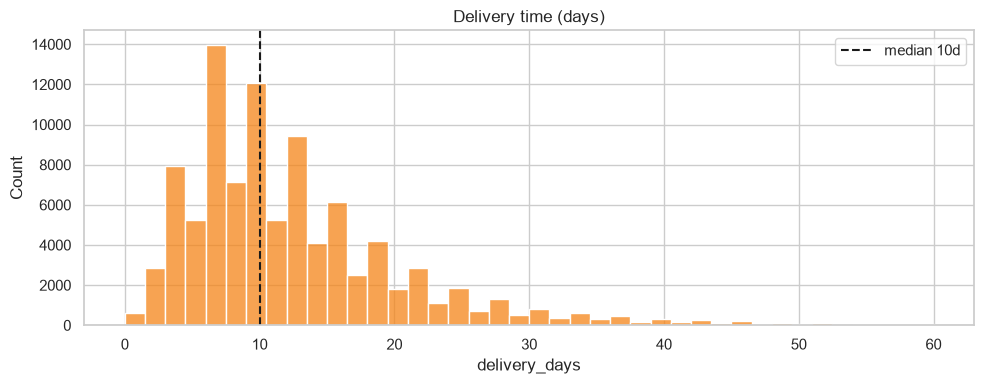

In [20]:
deliv = con.execute('''
  SELECT DISTINCT order_id, delivery_days FROM fct_order_items
  WHERE delivery_days IS NOT NULL AND delivery_days BETWEEN 0 AND 60
''').df()
fig, ax = plt.subplots(figsize=(10,4))
sns.histplot(deliv['delivery_days'], bins=40, ax=ax, color='#F58518')
ax.axvline(deliv['delivery_days'].median(), color='k', ls='--',
           label=f"median {deliv['delivery_days'].median():.0f}d")
ax.set_title('Delivery time (days)'); ax.legend(); plt.tight_layout()
plt.savefig('dashboard/screenshots/delivery_days.png', dpi=120); plt.show()

## Takeaways
_Fill these in from the numbers above — they become the README's headline findings:_

- Repeat rate = **`_%`** → acquisition-heavy, retention-weak.
- Revenue concentrates in **`_`** categories / **`_`** states.
- Cohort chart: retention collapses after month 0.
- Next: `02_ab_test.ipynb` tests whether delivery speed drives satisfaction.